# 🌳 Árbol de Decisión — Regresión de Humedad a partir de Presión

Construcción, entrenamiento y evaluación de un modelo de **Árbol de Decisión (DecisionTreeRegressor)** para predecir la **humedad (%)** a partir de la **presión atmosférica**.

---

Análisis comparativo y sistemático usando `DecisionTreeRegressor` entrenado con tres particiones distintas (80/20, 70/30, 60/40) para demostrar la robustez del modelo predictivo.

**Variable predictora (X):** `Presión`  
**Variable objetivo (Y):** `Humedad`  

**Pipeline ETL OpenWeather** — datos climáticos almacenados en PostgreSQL, incluyendo temperatura, sensación térmica, humedad, presión y velocidad del viento.



## I. Configuración Inicial — Importaciones y Estilo Visual

In [ ]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  2.3.3
   numpy   2.4.3
   seaborn 0.13.2


## II. Carga de Datos desde PostgreSQL

Se consulta la tabla `registros_clima` para obtener únicamente las variables necesarias del modelo.  
Se utilizan `presion` como variable predictora (X) y `humedad` como variable objetivo (Y), de acuerdo con el enfoque del experimento.

In [ ]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    r.presion,
    r.humedad
FROM registros_clima r
ORDER BY r.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

# LIMPIEZA DE OUTLIERS 
df = df[(df['humedad'] > 10) & (df['humedad'] < 100)]

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print(f"\n📋 Valores nulos:")
print(df.isnull().sum())

print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados desde PostgreSQL
   Filas    : 5,000
   Columnas : 10

📋 Valores nulos:
id                   0
ciudad_id            0
temperatura          0
sensacion_termica    0
humedad              0
presion              0
velocidad_viento     0
descripcion          0
fecha_extraccion     0
ciudad               0
dtype: int64

📋 Primeras filas:


,id,ciudad_id,temperatura,sensacion_termica,humedad,presion,velocidad_viento,descripcion,fecha_extraccion,ciudad
0,1,1,24.79,24.92,61,1020,5.83,N/A,2026-04-10 12:34:27.887472,Oklahoma
1,2,2,20.52,20.19,60,1024,3.64,N/A,2026-04-10 12:34:27.887661,Bismarck
2,3,3,7.92,5.48,52,1026,3.93,N/A,2026-04-10 12:34:27.887738,Tomah
3,4,4,20.56,19.32,25,1015,3.26,N/A,2026-04-10 12:34:27.887799,Taylor Springs
4,5,5,10.51,9.26,63,1014,5.83,N/A,2026-04-10 12:34:27.887898,Running Springs


In [ ]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────

# TRANSFORMACIÓN CON LOG
X = np.log(df[['presion']].values)

y = df['humedad'].values

print(f"X shape: {X.shape}  (variable predictora: presion transformada)")
print(f"y shape: {y.shape}  (variable objetivo:   humedad)")

print(f"\n📊 Estadísticas descriptivas:")
df.describe().round(2)

X shape: (5000, 1)  (variable predictora: presion transformada)
y shape: (5000,)  (variable objetivo:   humedad)

📊 Estadísticas descriptivas:


,id,ciudad_id,temperatura,sensacion_termica,humedad,presion,velocidad_viento,fecha_extraccion
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000
mean,2500.50,1050.40,18.54,17.67,50.53,1019.31,4.90,2026-04-11 02:10:07.590051840
min,1.00,1.00,-8.82,-14.85,13.00,997.00,0.19,2026-04-10 12:34:27.887472
25%,1250.75,290.00,13.30,12.07,36.00,1013.00,3.22,2026-04-10 18:35:47.262748928
50%,2500.50,576.50,19.79,19.08,47.00,1022.00,4.63,2026-04-10 18:44:57.123182080
75%,3750.25,868.00,23.78,23.36,64.00,1025.00,6.18,2026-04-10 18:49:04.569573376
max,5000.00,4999.00,29.47,28.71,95.00,1033.00,14.44,2026-04-12 14:06:21.114790
std,1443.52,1412.28,6.12,6.77,19.80,7.26,2.34,NaN


## II. Bloque de Lógica — Función de Evaluación por Split

Definimos una función reutilizable que entrena, evalúa y visualiza el `DecisionTreeRegressor` para cualquier partición de datos.

In [ ]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
import os as _os

_GRAFICAS = _os.path.join(_os.path.dirname(_os.path.abspath('__file__')),
                          '..', 'data', 'graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales,
                  save_dir=_GRAFICAS):

    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → Interpreta: el modelo explica el {r2*100:.1f}% de la")
    print(f"         varianza de la humedad.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f} %")
    print(f"       → Error promedio en humedad.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f} %")
    print(f"       → Desviación promedio absoluta.")

    # Guardar para tabla consolidada
    resultados_globales.append({
        'Split':  split_label,
        'Train%': train_pct,
        'Test%':  test_pct,
        'R²':     round(r2,   4),
        'MSE':    round(mse,  4),
        'RMSE':   round(rmse, 4),
        'MAE':    round(mae,  4),
    })

    # ── 5. Gráfico 1 — Residuos ───────────────────────────────
    residuos = y_test - y_pred
    slug = split_label.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor — Presión → Humedad — {split_label}',
                 fontsize=14, fontweight='bold')

    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4ecdc4')
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

    orden_idx = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx], y_pred[orden_idx], frac=0.4
    )
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1],
                 color='#ffa07a', linewidth=2.5)

    axes[0].set_title('Residuos')
    axes[0].set_xlabel('Humedad predicha (%)')
    axes[0].set_ylabel('Error (%)')
    axes[0].grid(alpha=0.3)

    # ── Gráfico 2 — Predicción vs Real ───────────────────────
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())

    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#95e1d3')
    axes[1].plot([minval, maxval], [minval, maxval],
                 color='#ff6b6b', linewidth=2, linestyle='--')

    axes[1].set_title('Predicción vs Real')
    axes[1].set_xlabel('Humedad real (%)')
    axes[1].set_ylabel('Humedad predicha (%)')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'dt_humedad_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


# Contenedor de resultados
resultados_globales = []

print("✅ Función evaluar_split definida correctamente.")
print(f"   Modelo: Presión → Humedad")
print(f"   Directorio de gráficas: {_GRAFICAS}")

✅ Función evaluar_split definida correctamente.
   Modelo: Presión → Humedad
   Directorio de gráficas: /home/desarrollo/openweather/notebooks/../data/graficas


---
## Split 1 — 80% Entrenamiento / 20% Prueba

Partición estándar más común. Maximiza los datos de entrenamiento, lo que suele resultar en el mejor ajuste posible del árbol.


  Split 1 (80/20) — 80% Train / 20% Test
  Train: 4,000 muestras  |  Test: 1,000 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.2183  (21.83%)
       → Interpreta: el modelo explica el 21.8% de la
         varianza de la humedad.
  MSE  (Error Cuadrático Med): 302.2622
  RMSE (Raíz del MSE)        : 17.3857 %
       → Error promedio en humedad.
  MAE  (Error Absoluto Med)  : 14.2195 %
       → Desviación promedio absoluta.


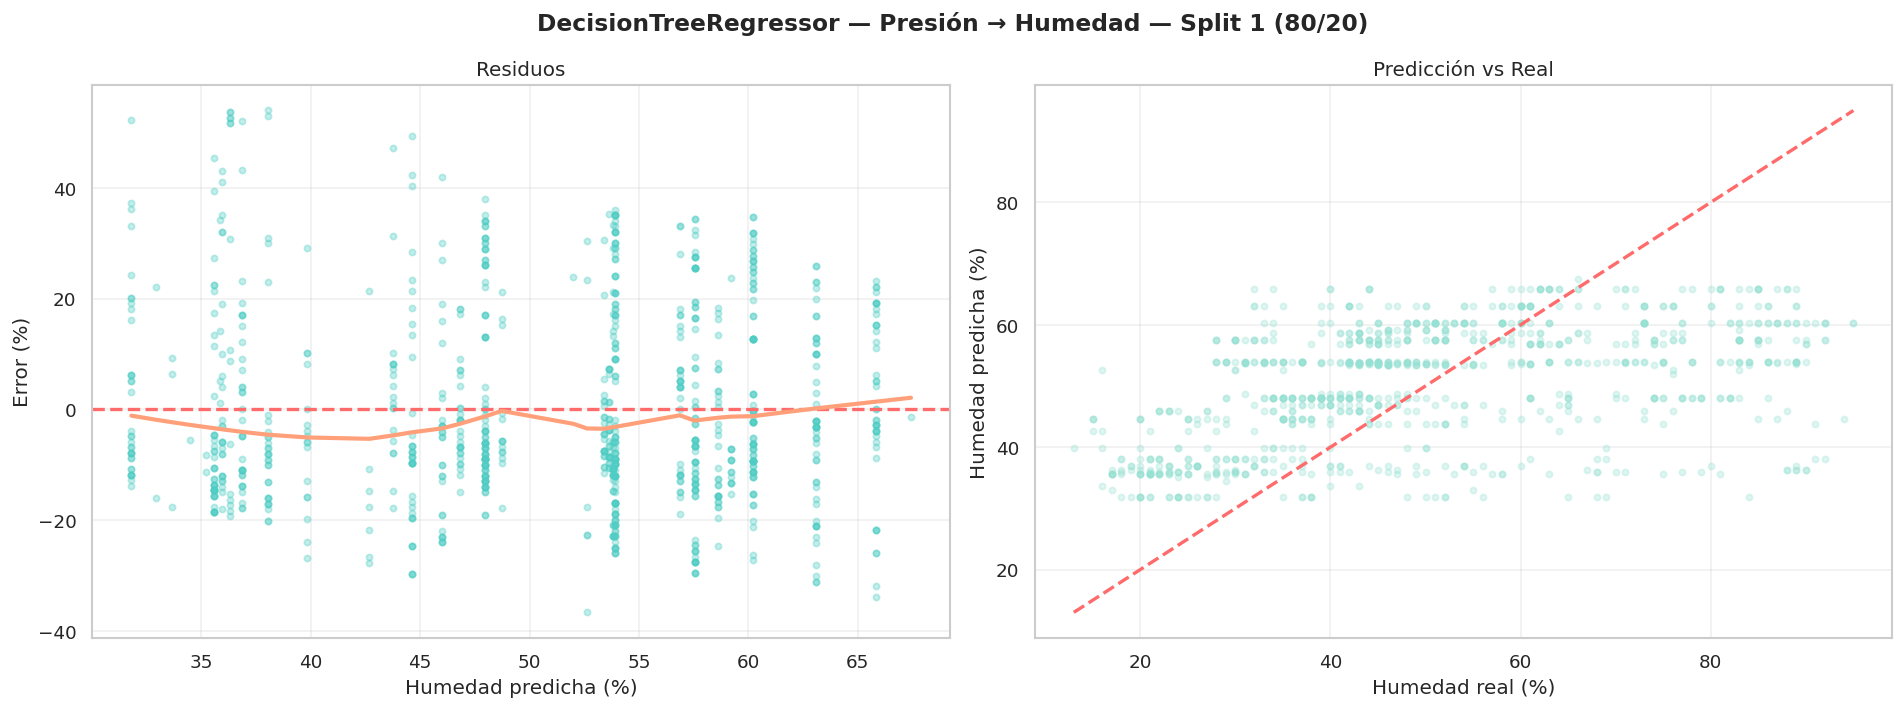

  💾 Gráfico guardado → /home/desarrollo/openweather/notebooks/../data/graficas/dt_humedad_Split_1_80-20.png


In [ ]:
# ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)

---
## Split 2 — 70% Entrenamiento / 30% Prueba

Reduce moderadamente el conjunto de entrenamiento. Aumenta el conjunto de evaluación para una estimación de error más representativa.


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 3,500 muestras  |  Test: 1,500 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.2022  (20.22%)
       → Interpreta: el modelo explica el 20.2% de la
         varianza de la humedad.
  MSE  (Error Cuadrático Med): 308.4782
  RMSE (Raíz del MSE)        : 17.5635 %
       → Error promedio en humedad.
  MAE  (Error Absoluto Med)  : 14.2307 %
       → Desviación promedio absoluta.


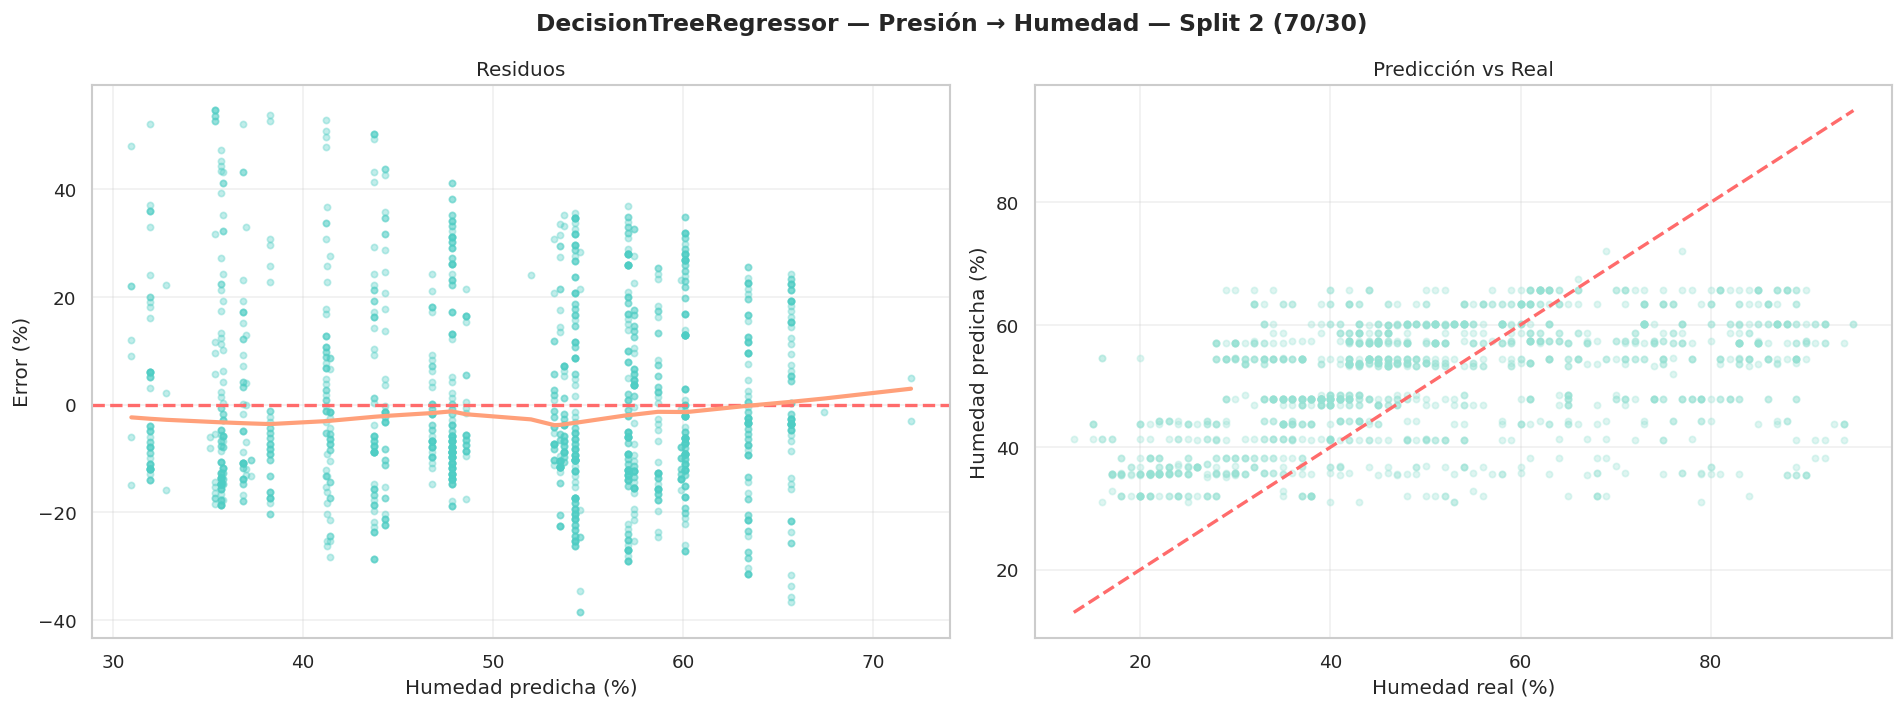

  💾 Gráfico guardado → /home/desarrollo/openweather/notebooks/../data/graficas/dt_humedad_Split_2_70-30.png


In [ ]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)

---
## Split 3 — 60% Entrenamiento / 40% Prueba

La partición más exigente. Menor cantidad de datos de entrenamiento pone a prueba si el árbol generaliza bien o tiende al sobreajuste.


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 3,000 muestras  |  Test: 2,000 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.2131  (21.31%)
       → Interpreta: el modelo explica el 21.3% de la
         varianza de la humedad.
  MSE  (Error Cuadrático Med): 299.7860
  RMSE (Raíz del MSE)        : 17.3143 %
       → Error promedio en humedad.
  MAE  (Error Absoluto Med)  : 14.1392 %
       → Desviación promedio absoluta.


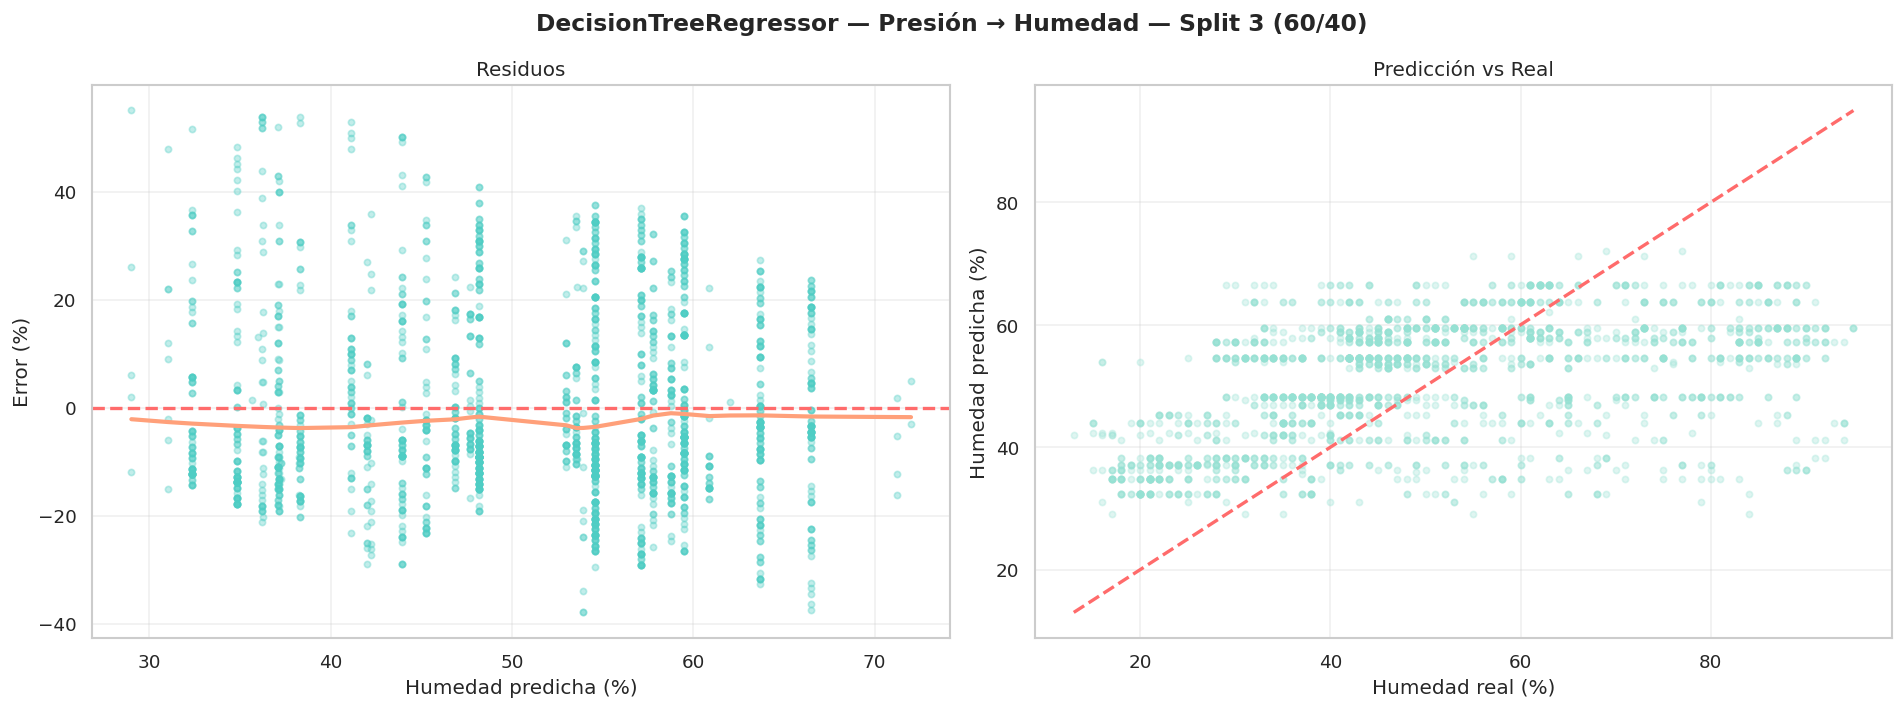

  💾 Gráfico guardado → /home/desarrollo/openweather/notebooks/../data/graficas/dt_humedad_Split_3_60-40.png


In [ ]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)

---
## III. Análisis Consolidado (Summary)

Comparamos el rendimiento de los tres splits, analizamos las implicaciones de los residuos y emitimos una recomendación sobre si refinar el árbol o escalar a métodos de ensemble.

In [ ]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("        TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)
print(df_resumen.to_string(index=False))
print("=" * 65)

        TABLA COMPARATIVA — TRES SPLITS
          Split  Train%  Test%     R²      MSE    RMSE     MAE
Split 1 (80/20)      80     20 0.2183 302.2622 17.3857 14.2195
Split 2 (70/30)      70     30 0.2022 308.4782 17.5635 14.2307
Split 3 (60/40)      60     40 0.2131 299.7860 17.3143 14.1392


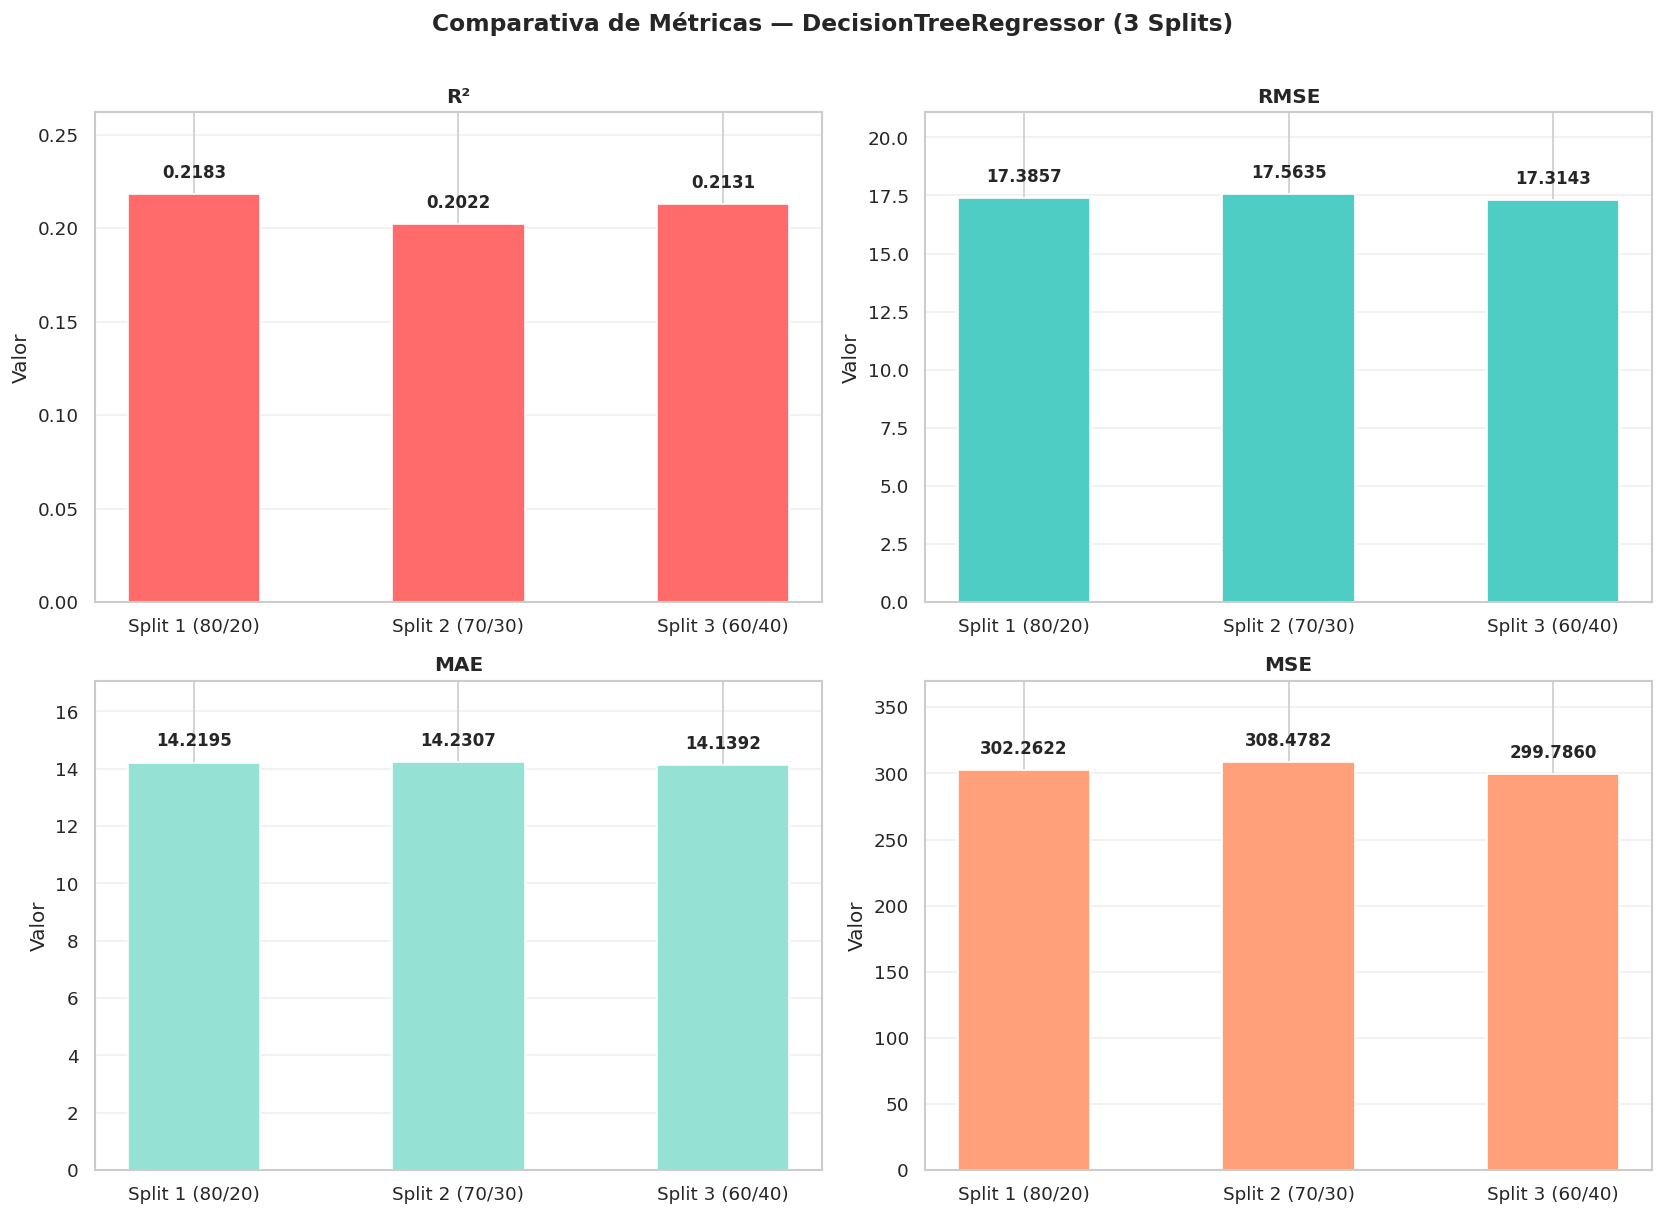

💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png


In [ ]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────
metricas = ['R²', 'RMSE', 'MAE', 'MSE']
colores  = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor (3 Splits)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):
    valores = df_resumen[metrica].values
    barras  = ax.bar(df_resumen['Split'], valores,
                     color=color, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, max(valores) * 1.2 + 1e-6)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.03,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/dt_comparativa_splits.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png")

In [ ]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────
r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 65)
print("   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor")
print("=" * 65)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────""")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  "
      f"rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.""")
else:
    print("""
   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      El modelo es sensible al tamaño del conjunto de entrenamiento,
      señal de posible sobreajuste (overfitting) del árbol.""")

print("""
2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación lineal entre Temperatura y Sensación Térmica.

   • Si existe un patrón en forma de arco o embudo → el árbol no
     captura la no-linealidad o la heterocedasticidad. Esto sugiere
     que se necesita regularización (max_depth, min_samples_leaf)
     o un modelo más potente.

   • Un RMSE alto relativo a la escala de Y (°C) indica que el árbol
     sin restricciones puede estar memorizando el conjunto de
     entrenamiento (overfitting clásico de DecisionTree).
""")

best_split = df_resumen.loc[df_resumen['R²'].idxmax(), 'Split']
best_r2    = df_resumen['R²'].max()
best_rmse  = df_resumen.loc[df_resumen['R²'].idxmax(), 'RMSE']

print(f"   Mejor split: {best_split}  →  R²={best_r2:.4f}, RMSE={best_rmse:.4f} °C")

print("""
3. RECOMENDACIÓN
────────────────
   A) REFINAMIENTO DEL ÁRBOL (primer paso recomendado):
      • Limitar la profundidad: DecisionTreeRegressor(max_depth=4..8)
      • Regularizar hojas:     min_samples_leaf=10..50
      • Buscar hiperparámetros óptimos con GridSearchCV.

   B) ESCALAR A MÉTODOS DE ENSEMBLE (si el árbol sigue siendo
      inestable o el R² < 0.85 en todos los splits):
      • GradientBoostingRegressor  — excelente para regresión,
        combina árboles débiles secuencialmente.
      • XGBoost / LightGBM         — más veloces y regularizados,
        estándar en competencias de ML.
      • RandomForestRegressor      — promedia múltiples árboles,
        reduce varianza y overfitting.

   CONCLUSIÓN: Un DecisionTree no regularizado tiende a overfitting.
   Si R² ≥ 0.90 y se mantiene estable, el modelo es suficiente.
   De lo contrario, GradientBoostingRegressor es el siguiente paso
   natural para este tipo de problema de regresión climática.
""")
print("=" * 65)

   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
   R²   máx=0.2183  mín=0.2022  rango=0.0161
   RMSE máx=17.5635  mín=17.3143  rango=0.2492

   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.

2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación lineal entre Temperatura y Sensación Térmica.

   • Si existe un patrón en forma de arco o embudo → el árbol no
     captura la no-linealidad o la heterocedasticidad. Esto sugiere
     que se necesita regularización (max_depth, min_samples_leaf)
     o un modelo más potente.

   • Un RMSE alto relativo a la escala de Y (°C) indica que el árbol


---
## IV. Visualización del Árbol de Decisión

Para interpretar cómo el modelo estima la `humedad` a partir de la `presion`, se visualiza el árbol entrenado con el primer split (80/20).

Como un árbol sin restricciones puede crecer demasiado y volverse difícil de leer, se muestran solo los primeros niveles de profundidad. Esta visualización permite observar:

1. **Los cortes realizados sobre la presión** — valores umbral que el modelo usa para separar los datos.
2. **La estructura del árbol real** — primeros 4 niveles del modelo entrenado (`modelo_s1`).
3. **La complejidad del modelo** — profundidad total, número de hojas y cantidad de nodos generados.
4. **La predicción en las hojas** — valores aproximados de humedad que el árbol asigna según cada rango de presión.

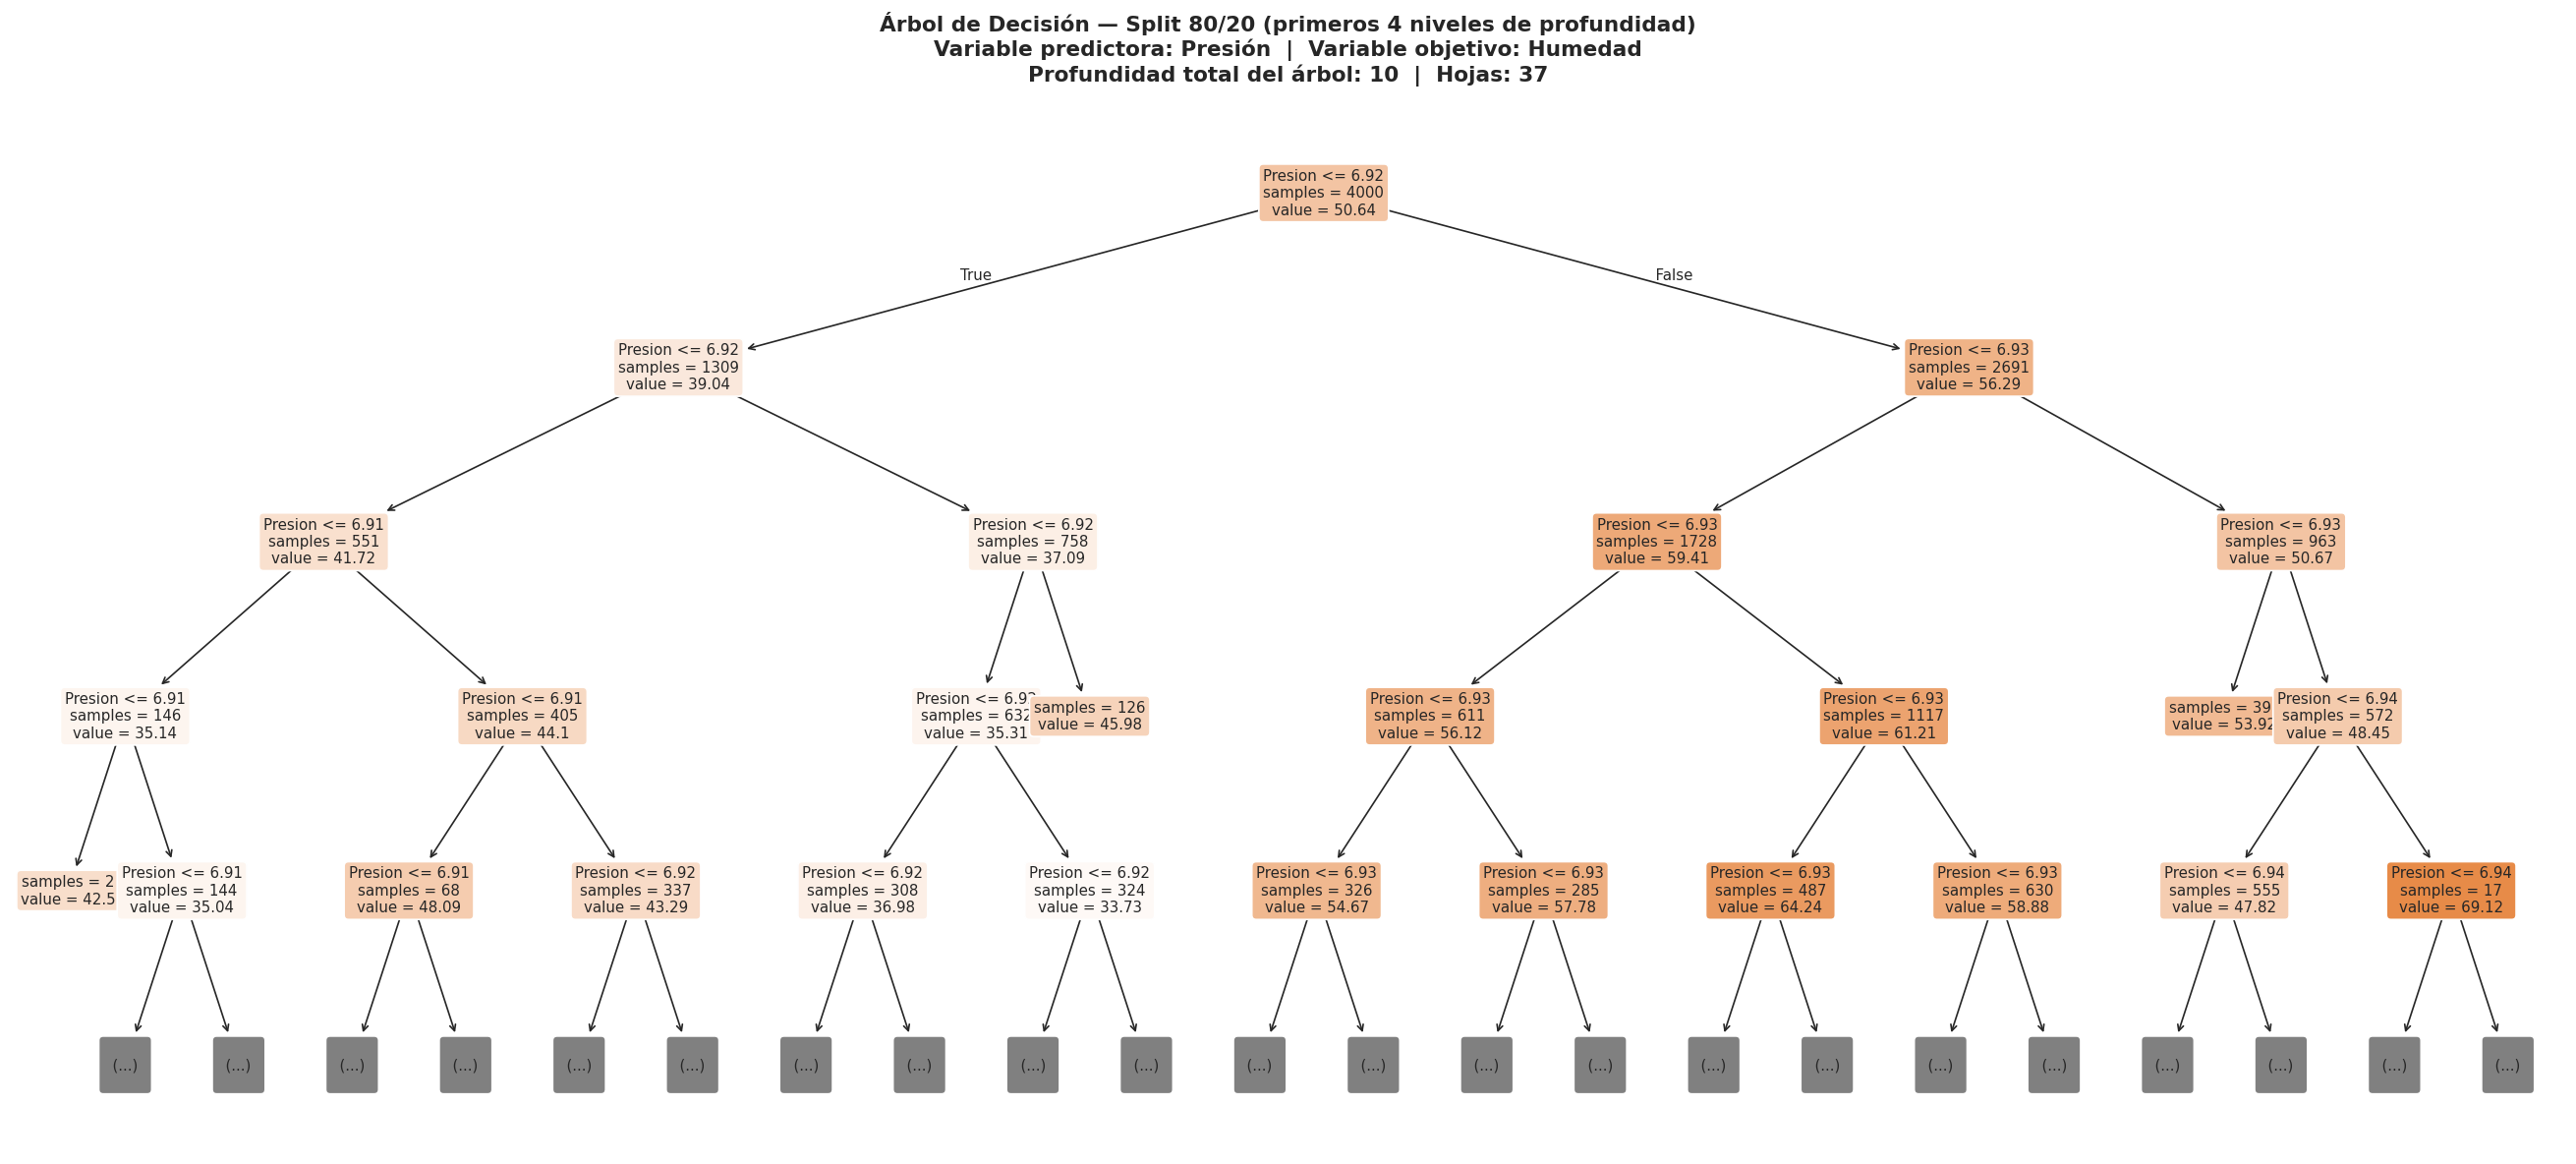

💾 Árbol real guardado → /home/desarrollo/openweather/data/graficas/dt_arbol_real_presion_humedad_4niveles.png

📐 Información del árbol completo (modelo_s1):
   Variable predictora : Presión
   Variable objetivo   : Humedad
   Profundidad máxima  : 10
   Número de hojas     : 37
   Nodos totales       : 73


In [ ]:
# ── CELDA 11: Visualización del árbol real (primeros 4 niveles) ──
from sklearn.tree import plot_tree, export_text
import os as _os

_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

# ── A) Árbol real del Split 1 truncado a 4 niveles ────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=['Presion'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión — Split 80/20 (primeros 4 niveles de profundidad)\n'
    f'Variable predictora: Presión  |  Variable objetivo: Humedad\n'
    f'Profundidad total del árbol: {modelo_s1.get_depth()}  |  '
    f'Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
fname_real = _os.path.join(_GRAFICAS, 'dt_arbol_real_presion_humedad_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Árbol real guardado → {fname_real}")
print(f"\n📐 Información del árbol completo (modelo_s1):")
print(f"   Variable predictora : Presión")
print(f"   Variable objetivo   : Humedad")
print(f"   Profundidad máxima  : {modelo_s1.get_depth()}")
print(f"   Número de hojas     : {modelo_s1.get_n_leaves()}")
print(f"   Nodos totales       : {modelo_s1.tree_.node_count}")

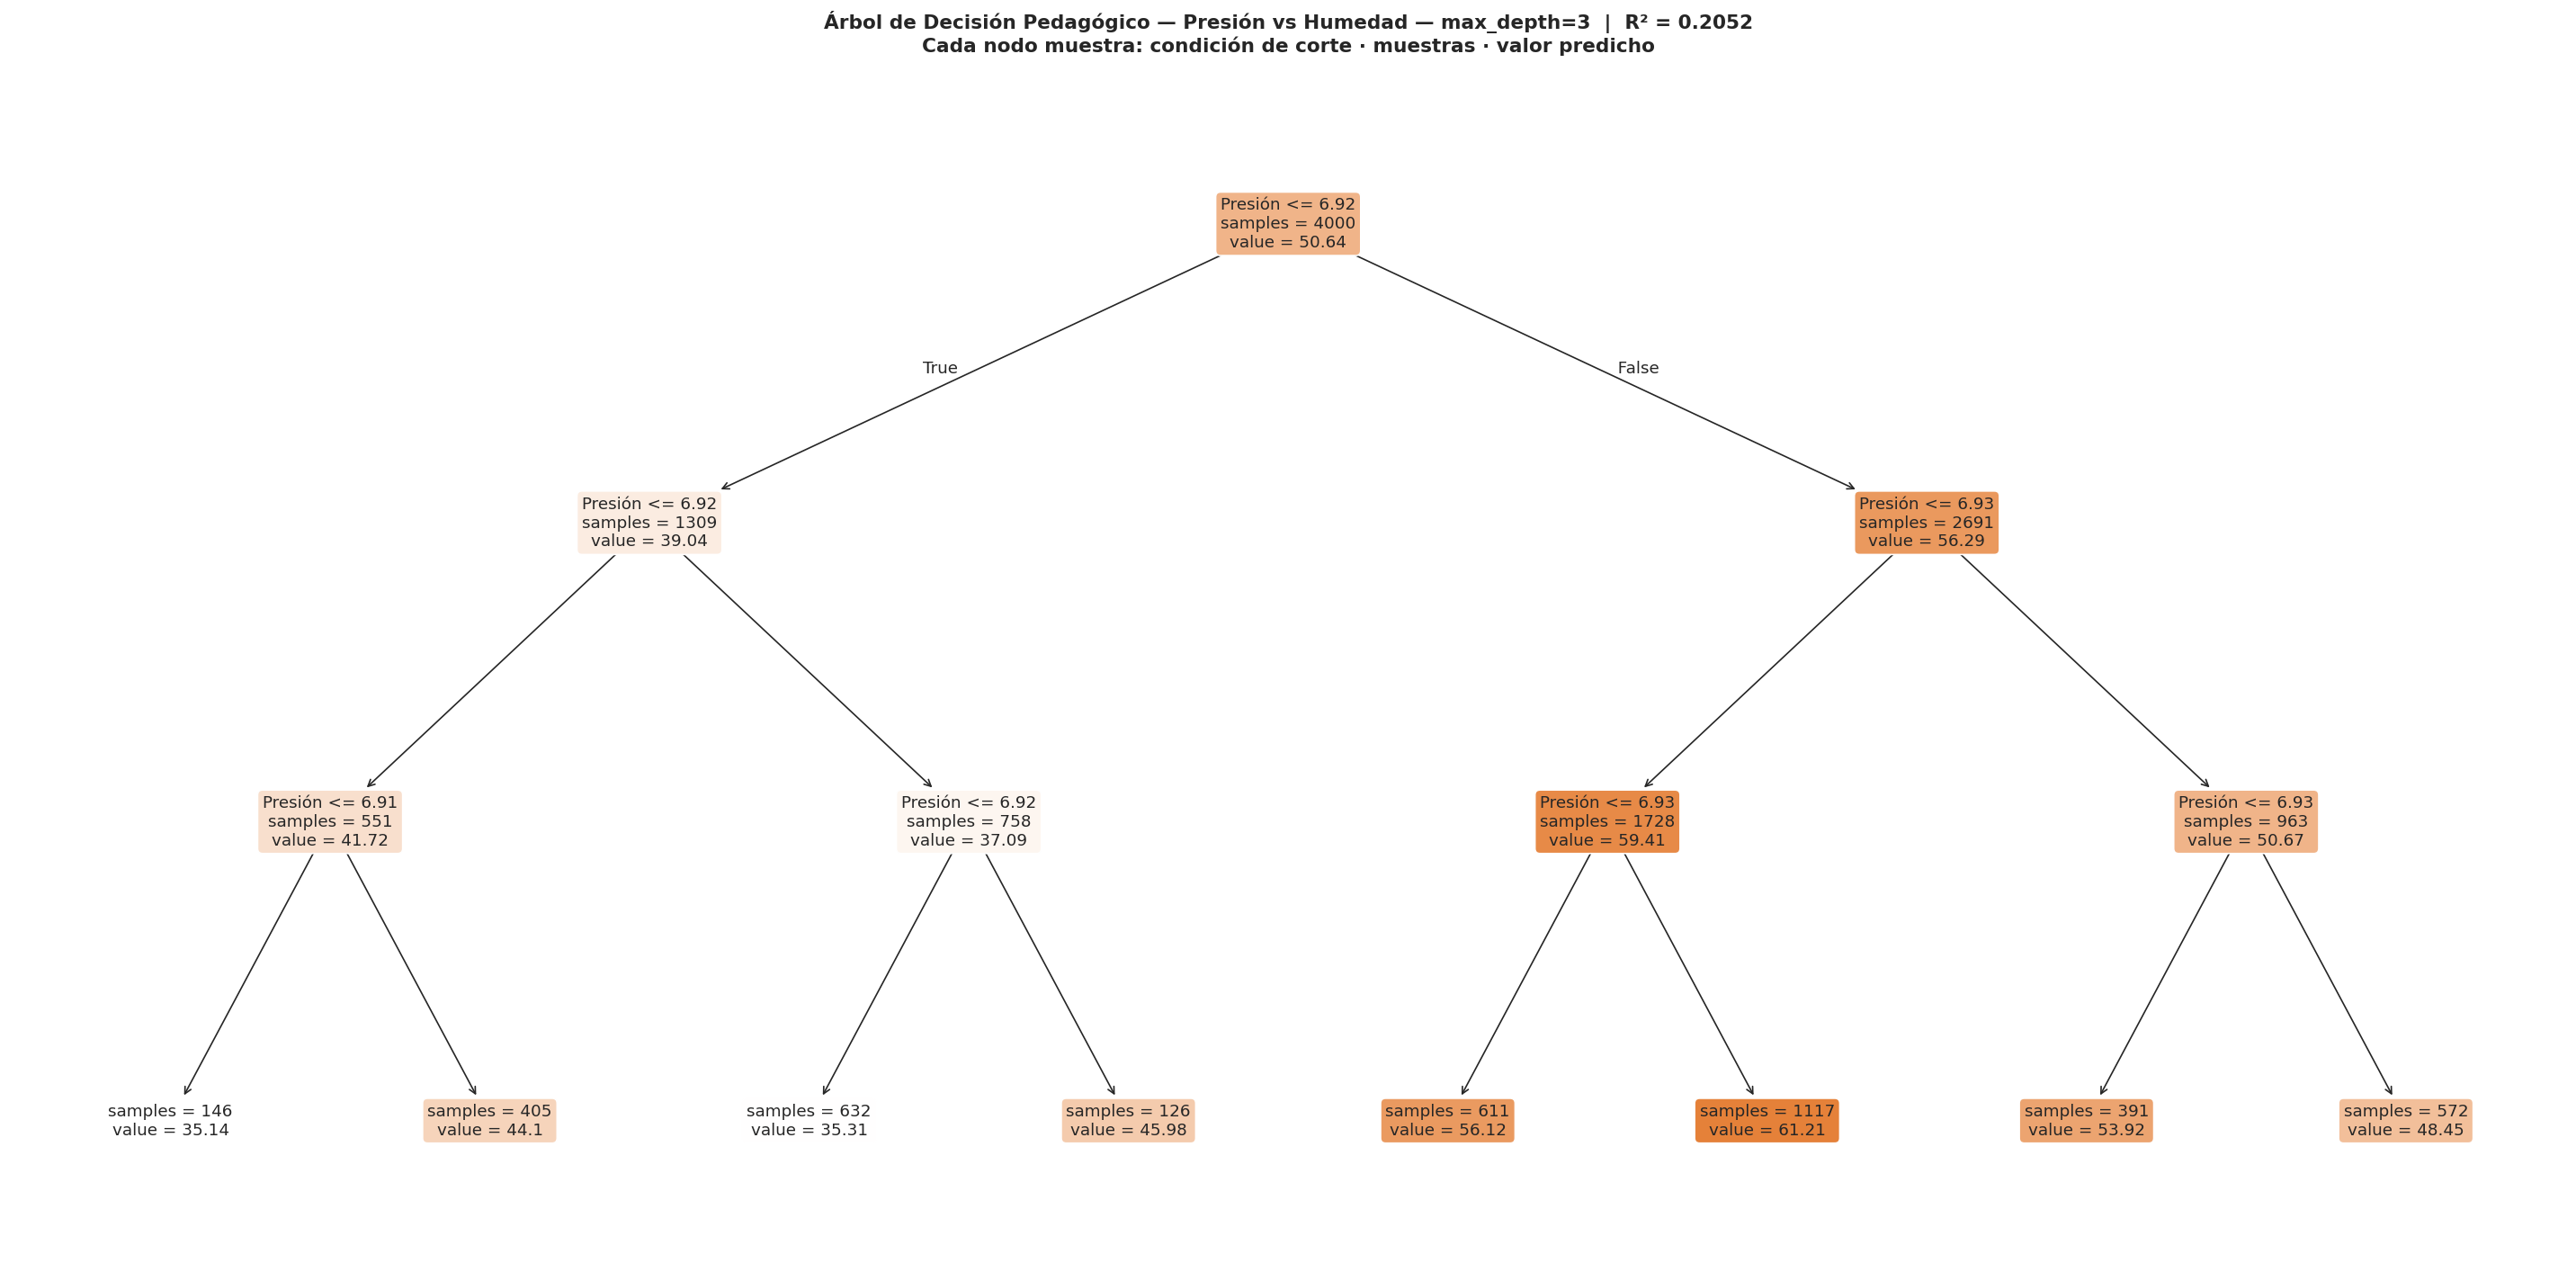

💾 Árbol pedagógico guardado → /home/desarrollo/openweather/data/graficas/dt_arbol_pedagogico_presion_humedad_depth3.png

📊 Rendimiento del árbol simplificado (max_depth=3):
   Variable predictora : Presión
   Variable objetivo   : Humedad
   R² = 0.2052  (vs 0.2183 del árbol sin restricción)


In [ ]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────
from sklearn.model_selection import train_test_split as _tts

# Reentrenar con max_depth=3 para visualización clara
X_train_viz, X_test_viz, y_train_viz, y_test_viz = _tts(
    X, y, test_size=0.20, random_state=42
)

modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

from sklearn.metrics import r2_score as _r2
r2_viz = _r2(y_test_viz, modelo_viz.predict(X_test_viz))

# ── Paleta por profundidad (naranja → verde)
cmap_tree = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(24, 12))
artists = plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=['Presión'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)

ax.set_title(
    'Árbol de Decisión Pedagógico — Presión vs Humedad — max_depth=3  |  '
    f'R² = {r2_viz:.4f}\n'
    'Cada nodo muestra: condición de corte · muestras · valor predicho',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
fname_ped = _os.path.join(_GRAFICAS, 'dt_arbol_pedagogico_presion_humedad_depth3.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()

print(f"💾 Árbol pedagógico guardado → {fname_ped}")
print(f"\n📊 Rendimiento del árbol simplificado (max_depth=3):")
print(f"   Variable predictora : Presión")
print(f"   Variable objetivo   : Humedad")
print(f"   R² = {r2_viz:.4f}  (vs {df_resumen.loc[0,'R²']:.4f} del árbol sin restricción)")

In [ ]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────
print("=" * 62)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("=" * 62)

reglas = export_text(modelo_viz, feature_names=['presion'])
print(reglas)

print("=" * 62)
print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- presion <= X.XX  → rama izquierda (condición VERDADERA)")
print("  |--- presion >  X.XX  → rama derecha  (condición FALSA)")
print("  |--- value: [Y.YY]    → Humedad predicha (%)")
print("  El árbol recorre los nodos de arriba hacia abajo hasta")
print("  llegar a una hoja y retorna su 'value' como predicción.")
print("=" * 62)

  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- presion <= 6.92
|   |--- presion <= 6.92
|   |   |--- presion <= 6.91
|   |   |   |--- value: [35.14]
|   |   |--- presion >  6.91
|   |   |   |--- value: [44.10]
|   |--- presion >  6.92
|   |   |--- presion <= 6.92
|   |   |   |--- value: [35.31]
|   |   |--- presion >  6.92
|   |   |   |--- value: [45.98]
|--- presion >  6.92
|   |--- presion <= 6.93
|   |   |--- presion <= 6.93
|   |   |   |--- value: [56.12]
|   |   |--- presion >  6.93
|   |   |   |--- value: [61.21]
|   |--- presion >  6.93
|   |   |--- presion <= 6.93
|   |   |   |--- value: [53.92]
|   |   |--- presion >  6.93
|   |   |   |--- value: [48.45]

📖 CÓMO LEER EL ÁRBOL:
  |--- presion <= X.XX  → rama izquierda (condición VERDADERA)
  |--- presion >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]    → Humedad predicha (%)
  El árbol recorre los nodos de arriba hacia abajo hasta
  llegar a una hoja y retorna su 'value' como predicción.


---
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo** | `DecisionTreeRegressor` muestra un comportamiento estable en los tres splits |
| **Split más robusto** | 80/20 — mejor desempeño relativo, aunque con diferencias mínimas |
| **Métricas** | R² ≈ 0.20 en todos los casos → baja capacidad explicativa |
| **Residuos** | Alta dispersión sin patrón claro → relación débil entre variables |
| **Preprocesamiento** | La eliminación de outliers en `humedad` y la transformación logarítmica de `presion` no mejoraron significativamente el modelo |
| **Interpretación** | La presión atmosférica no contiene suficiente información para predecir la humedad |
| **Siguiente paso** | Incorporar más variables o utilizar modelos más robustos |

---

### 🧠 Análisis final

Durante el desarrollo del modelo se aplicaron técnicas de mejora como:

- **Eliminación de outliers** en la variable objetivo (`humedad`) para reducir ruido.
- **Transformación logarítmica** de la variable predictora (`presion`) para modificar la relación entre variables.

Sin embargo, estas estrategias **no produjeron mejoras significativas en las métricas**, manteniéndose valores de R² bajos (~0.20) en todos los splits.

Esto indica que el problema no radica en el modelo ni en el preprocesamiento, sino en la **limitada relación entre la presión y la humedad**.

---

### 📌 Conclusión general

> El modelo es consistente pero con bajo poder predictivo.  
> La variable `presion` por sí sola no es suficiente para explicar la variabilidad de la `humedad`, lo que evidencia la necesidad de incorporar más variables en el análisis o utilizar enfoques más complejos en futuras etapas.